# 2. Ajuste de las distribuciones de la irradiación, la temperatura y la precipitación en la celda 01.
## Importación y carga de datos
En esta sección importaremos los datos necesarios para el análisis del apartado 2.

In [7]:
from carga_de_datos import *

## 2.1. Mediante la aplicación del contraste de hipótesis de Kolmogorov-Smirnov (KS), con un nivel de significación del 3%, determinar si las variables de irradiación, temperatura y precipitación de cada trimestre en la celda 01 siguen una distribución normal. Apoyar la respuesta mediante qqplots.


Vamos a comenzar definiendo algunas funciones que usaremos para ejecutar todo el código directamente, y no tener que repetirnos.

In [ ]:
def contraste_ks(x):
    # realiza el test
    ks = sm.stats.diagnostic.kstest_normal(x, dist='norm', pvalmethod='table')

    max_d   = ks[0]
    p_valor = ks[1]

    print(f"Máxima distancia observada = {max_d} -> p_valor = {p_valor}")

    return max_d, p_valor

def qqplot(x, p_valor, dist):
    # Gráfico qqplot con contraste KS
    titulo = f"KS test:  p_valor = {p_valor}"

    # genera qqplot de la variable x añadiendo en el título el resultado del KS
    sm.qqplot(x, line='45', fit=True, dist=dist)
    plt.title(titulo)
    plt.grid(); plt.show()

### Empezamos con el análisis de la temperatura en la celda 01.

Máxima distancia observada = 0.09245602389930385 -> p_valor = 0.0009999999999998899


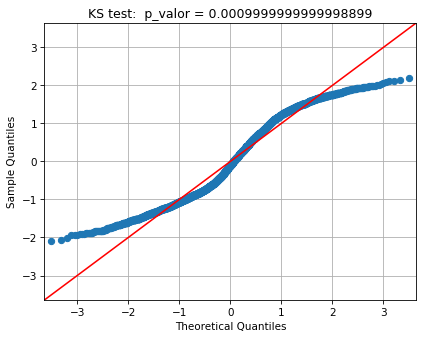

Como el pvalor < 0.03, se puede rechazar H0 con un nivel de significación del 3.0% ya que la distancia máxima observada es suficientemente grande.
Según el test no paramétrico KS se puede afirmar, con un nivel de significación del 3.0%, que los datos de la muestra no siguen una distribución normal.
Esto encaja perfectamente con lo que observamos en el QQ-Plot, ya que las colas no se parecen nada a la distribución teórica (una normal).


In [ ]:
# Elegimos lo que vamos a analizar
x = df_orig_temp.TEMP_CELDA01
alfa = 0.03

max_d, p_valor = contraste_ks(x)

qqplot(x, p_valor, dist=stats.norm)

# Conclusión
print(f"Como el pvalor < {alfa}, se puede rechazar H0 con un nivel de significación del {alfa*100}% ya que la distancia máxima observada es suficientemente grande.")
print(f"Según el test no paramétrico KS se puede afirmar, con un nivel de significación del {alfa*100}%, que los datos de la muestra no siguen una distribución normal.")
print("Esto encaja perfectamente con lo que observamos en el QQ-Plot, ya que las colas no se parecen nada a la distribución teórica (una normal).")

### Ahora continuamos con el análisis de la irradiación en la celda 01.

Máxima distancia observada = 0.08593024300965191 -> p_valor = 0.0009999999999998899


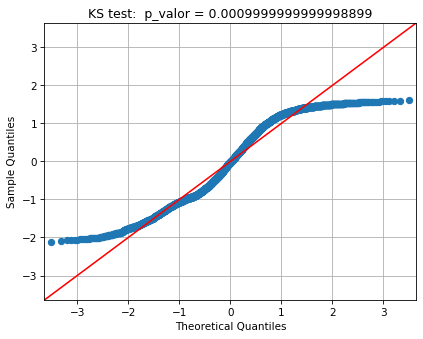

Como el pvalor < 0.03, se puede rechazar H0 con un nivel de significación del 3.0% ya que la distancia máxima observada es suficientemente grande.
Según el test no paramétrico KS se puede afirmar, con un nivel de significación del 3.0%, que los datos de la muestra no siguen una distribución normal.
Esto encaja perfectamente con lo que observamos en el QQ-Plot, ya que las colas no se parecen nada a la distribución teórica (una normal).


In [10]:
# Elegimos lo que vamos a analizar
x = df_orig_irrad.IRRAD_CELDA01
alfa = 0.03

max_d, p_valor = contraste_ks(x, alfa)

qqplot(x, p_valor, dist=stats.norm)

# Conclusión
print(f"Como el pvalor < {alfa}, se puede rechazar H0 con un nivel de significación del {alfa*100}% ya que la distancia máxima observada es suficientemente grande.")
print(f"Según el test no paramétrico KS se puede afirmar, con un nivel de significación del {alfa*100}%, que los datos de la muestra no siguen una distribución normal.")
print("Esto encaja perfectamente con lo que observamos en el QQ-Plot, ya que las colas no se parecen nada a la distribución teórica (una normal).")

### Por último, el análisis de la precipitación en la celda 01.

Máxima distancia observada = 0.36516944397467516 -> p_valor = 0.0009999999999998899


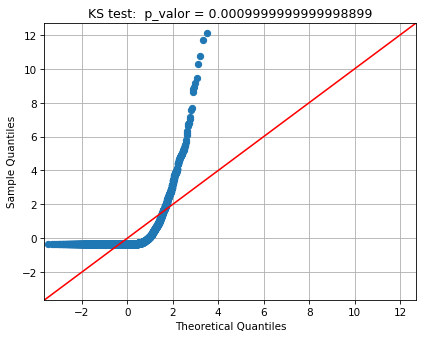

Como el pvalor < 0.03, se puede rechazar H0 con un nivel de significación del 3.0% ya que la distancia máxima observada es suficientemente grande.
Según el test no paramétrico KS se puede afirmar, con un nivel de significación del 3.0%, que los datos de la muestra no siguen una distribución normal.
Esto encaja perfectamente con lo que observamos en el QQ-Plot, ya que las colas no se parecen nada a la distribución teórica (una normal).


In [11]:
# Elegimos lo que vamos a analizar
x = df_orig_precip.PRECIP_CELDA01
alfa = 0.03

max_d, p_valor = contraste_ks(x, alfa)

qqplot(x, p_valor, dist=stats.norm)

# Conclusión
print(f"Como el pvalor < {alfa}, se puede rechazar H0 con un nivel de significación del {alfa*100}% ya que la distancia máxima observada es suficientemente grande.")
print(f"Según el test no paramétrico KS se puede afirmar, con un nivel de significación del {alfa*100}%, que los datos de la muestra no siguen una distribución normal.")
print("Esto encaja perfectamente con lo que observamos en el QQ-Plot, ya que las colas no se parecen nada a la distribución teórica (una normal).")

## 2.2. Para las variables de irradiación, temperatura y precipitación de la celda 01 (sin separar por trimestres), ajustar, por un lado, las siguientes distribuciones teóricas: uniforme, exponencial, normal, beta y triangular, y por otro lado, un kernel. Para cada variable, representar todas las distribuciones en una misma gráfica y discutir qué distribución escoger en cada caso, teniendo en cuenta el sentido físico de la variable y la complejidad de la distribución ajustada. 

### Definimos los datos y las funciones que vamos a necesitar.

In [64]:
# Definimos las variables que vamos a analizar.
temp01 = df_orig_temp.TEMP_CELDA01
irrad01 = df_orig_irrad.IRRAD_CELDA01
precip01 = df_orig_precip.PRECIP_CELDA01

# Indica la lista de distribuciones continuas que se prueban.
dist_names = ['uniform', 'norm', 'triang', 'expon', 'beta']

def adjust_distributions(x, dist_names):
    x = np.array(x)
    n = np.size(x)
    xs = np.linspace(min(x)-np.std(x),max(x)+np.std(x), 5000)
        
    plt.figure(1, figsize=(15, 6))
    plt.hist(x, bins=40, density = True, alpha = 0.4)
        
    # crea contendor con los resultados para elegir al final
    res_aju_distr = []
        
    for dist_name in dist_names:
        dist = getattr(stats, dist_name)
        params = dist.fit(x)
        arg = params[:-2]
        loc = params[-2]
        scale = params[-1]
        
        if arg:
            pdf_fitted = dist.pdf(xs, *arg, loc=loc, scale=scale)
            logLikelihood_med = np.sum(dist.logpdf(x, *arg, loc=loc, scale=scale)) / n
        else:
            pdf_fitted = dist.pdf(xs, loc=loc, scale=scale)
            logLikelihood_med = np.sum(dist.logpdf(x, loc=loc, scale=scale)) / n

        # guarda resultado para mostrarlo al final
        res_aju_distr.append((dist_name, logLikelihood_med, params))
            
        print(f'{dist_name} :: \t logLikelihood_med = {logLikelihood_med} \t params:{params}')
        plt.plot(xs, pdf_fitted, linewidth = 3, label=f'logLikelihood_med({dist_name}) = {logLikelihood_med}' )
        
    plt.legend(loc='upper left')

    # tabla de resultados, ordenada de peor a mejor según logLikelihood_med
    res_aju_distr_ord = sorted(res_aju_distr, key=lambda x:x[1])
    res_df = pd.DataFrame(res_aju_distr_ord, columns = ['Distribución', 'Media verosimilitud log', 'Parámetros'])
    print("\nVerosimilitudes de cada una de las distribuciones paramétricas:")
    print(res_df)

def kernel_density_estimation(x):
    x = np.array(x)
    n = np.size(x)

    # fija la función kernel a utilizar
    kernel_fun = 'gau'

    # fija el bandwidth
    tipo_bw = 'auto'

    if tipo_bw == 'auto':
        bandwidth = 'normal_reference' 
    else:
        bandwidth = 0.6 

        
    # estima kde
    kde = KDEUnivariate(x)
    kde.fit(kernel = kernel_fun, bw = bandwidth, fft = True)

    # calcula verosimilitud log media de ambas aproximaciones
    logLikelihood_med_kde = np.sum(np.log(kde.evaluate(x))) / n

    print(f'Verosimilitud logarítmica media de KDE: {logLikelihood_med_kde}')

    plt.plot(kde.support, kde.density, color = 'black', linewidth = 3, label =f'pdf KDE bw={kde.bw}')

    # marca el máximo
    index_max_pdf = np.argmax(kde.density)   # <--- encuentra el argumento que hace máximo la función
    x_max_pdf = kde.support[index_max_pdf]
    max_pdf = kde.density[index_max_pdf]
    plt.plot(x_max_pdf, max_pdf, 's', color = 'green', markersize = 10, label =f'max pdf KDE ({x_max_pdf}, {max_pdf})')

    sns.rugplot(x, height = 0.025, lw = 0.4, color = 'red')
    plt.title(f'KDE con bandwidth = {kde.bw} | bw fijado con método: {kde.bw_method}')
    plt.grid(); plt.legend()
    plt.show()

### Análisis de la temperatura

uniform :: 	 logLikelihood_med = -3.541911815201085 	 params:(1.7460734, 34.5328766)
norm :: 	 logLikelihood_med = -3.505820218990348 	 params:(np.float64(18.622822818822726), np.float64(8.059743125986543))
triang :: 	 logLikelihood_med = -3.4375419209911797 	 params:(np.float64(0.2852643846843769), np.float64(1.7239338685154788), np.float64(36.831829557286525))
expon :: 	 logLikelihood_med = -3.825936900648876 	 params:(1.7460734, 16.876749418822726)
beta :: 	 logLikelihood_med = -3.427142356884465 	 params:(np.float64(1.9194175732261396), np.float64(1.9805752978019804), np.float64(1.7195776840472439), np.float64(34.63051080413145))

Verosimilitudes de cada una de las distribuciones paramétricas:
  Distribución  Media verosimilitud log  \
0        expon                -3.825937   
1      uniform                -3.541912   
2         norm                -3.505820   
3       triang                -3.437542   
4         beta                -3.427142   

                                  

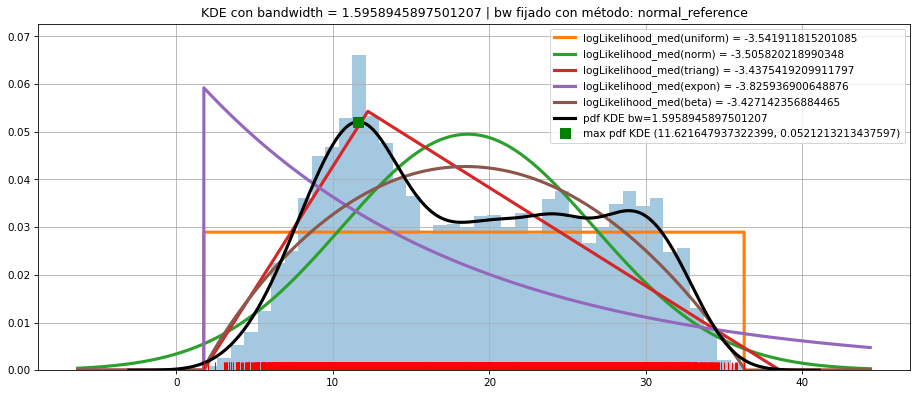


De las distribuciones paramétricas, las que mejor se adaptan son la triangular y la beta. Entre estas dos nos decantamos por la triangular, ya que tiene 3 parámetros (y la beta tiene 4).

Ahora lo comparamos con el kernel. Podemos ver en el gráfico que el kernel se adapta mucho mejor a la distribución, y además sabemos que los datos son de temperatura, y no encaja que sigan una triangular.


In [65]:
adjust_distributions(temp01, dist_names)
kernel_density_estimation(temp01)

print("\nDe las distribuciones paramétricas, las que mejor se adaptan son la triangular y la beta. Entre estas dos nos decantamos por la triangular, ya que tiene 3 parámetros (y la beta tiene 4).")
print("\nAhora lo comparamos con el kernel. Podemos ver en el gráfico que el kernel se adapta mucho mejor a la distribución, y además sabemos que los datos son de temperatura, y no encaja que sigan una triangular.")

### Análisis de la irradiación

uniform :: 	 logLikelihood_med = -14.06109978026326 	 params:(31197.162, 1278374.338)
norm :: 	 logLikelihood_med = -14.161781059253663 	 params:(np.float64(755625.1887946612), np.float64(342094.5794969391))
triang :: 	 logLikelihood_med = -14.043014530033323 	 params:(np.float64(0.9640841834647736), np.float64(-110483.64769757228), np.float64(1420888.0004384872))
expon :: 	 logLikelihood_med = -14.493137693909812 	 params:(31197.162, 724428.0267946612)
beta :: 	 logLikelihood_med = -14.012984901216125 	 params:(np.float64(1.4789482005213581), np.float64(1.106535594233656), np.float64(30625.394292399964), np.float64(1278977.857975699))

Verosimilitudes de cada una de las distribuciones paramétricas:
  Distribución  Media verosimilitud log  \
0        expon               -14.493138   
1         norm               -14.161781   
2      uniform               -14.061100   
3       triang               -14.043015   
4         beta               -14.012985   

                                

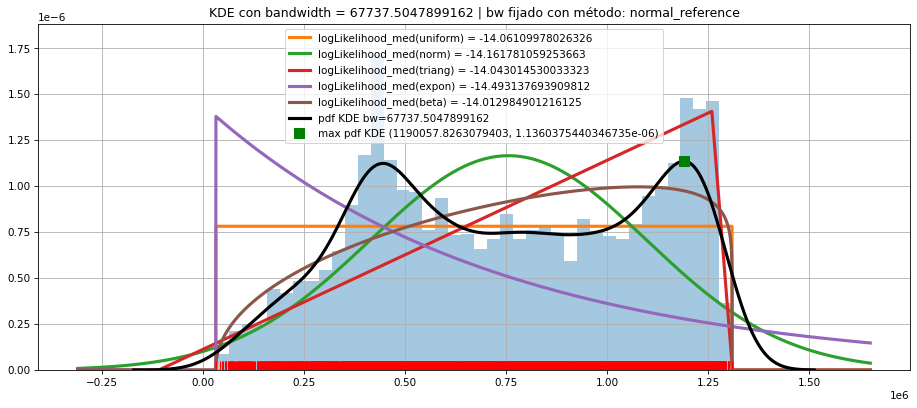


De las distribuciones paramétricas, las que mejor se adaptan son la triangular y la beta (igual que antes). Entre estas dos nos decantamos por la triangular, ya que tiene 3 parámetros (y la beta tiene 4).

Ahora lo comparamos con el kernel. Podemos ver en el gráfico que el kernel se adapta mucho mejor a la distribución, y además sabemos que los datos son de irradiación, y no encaja que sigan una triangular.


In [67]:
adjust_distributions(irrad01, dist_names)
kernel_density_estimation(irrad01)

print("\nDe las distribuciones paramétricas, las que mejor se adaptan son la triangular y la beta (igual que antes). Entre estas dos nos decantamos por la triangular, ya que tiene 3 parámetros (y la beta tiene 4).")
print("\nAhora lo comparamos con el kernel. Podemos ver en el gráfico que el kernel se adapta mucho mejor a la distribución, y además sabemos que los datos son de irradiación, y no encaja que sigan una triangular.")

### Análisis de la precipitación

uniform :: 	 logLikelihood_med = 6.39306268160538 	 params:(0.0, 0.0016731241)
norm :: 	 logLikelihood_med = 7.49432137811667 	 params:(np.float64(4.6395883319508465e-05), np.float64(0.00013459235889848474))
triang :: 	 logLikelihood_med = 7.046925079006442 	 params:(np.float64(1.1569123053202059e-09), np.float64(-7.012781083035033e-12), np.float64(0.001681664551095005))
expon :: 	 logLikelihood_med = 8.978299824230373 	 params:(0.0, 4.6395883319508465e-05)


c:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
c:\Users\User\anaconda3\Lib\site-packages\scipy\stats\_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


beta :: 	 logLikelihood_med = 15.344322180280084 	 params:(np.float64(0.215554992236624), np.float64(244.44240356690347), np.float64(-3.651452321621044e-30), np.float64(0.005676448510223973))

Verosimilitudes de cada una de las distribuciones paramétricas:
  Distribución  Media verosimilitud log  \
0      uniform                 6.393063   
1       triang                 7.046925   
2         norm                 7.494321   
3        expon                 8.978300   
4         beta                15.344322   

                                          Parámetros  
0                                (0.0, 0.0016731241)  
1  (1.1569123053202059e-09, -7.012781083035033e-1...  
2   (4.6395883319508465e-05, 0.00013459235889848474)  
3                      (0.0, 4.6395883319508465e-05)  
4  (0.215554992236624, 244.44240356690347, -3.651...  
Verosimilitud logarítmica media de KDE: 10.140725741588152


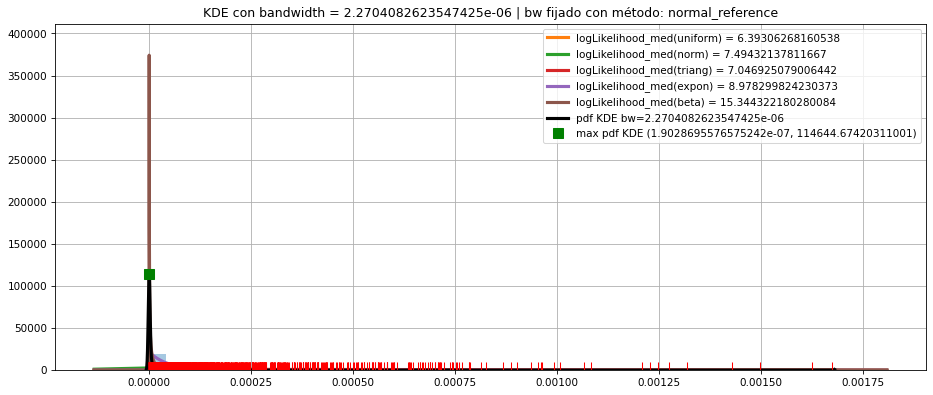


Ahora podemos ver claramente que la beta es la que mejores resultados da, ya que tiene verosimilitud mayor que las otras distribuciones paramétricas, e incluso mayor que el kernel.


In [69]:
adjust_distributions(precip01, dist_names)
kernel_density_estimation(precip01)

print("\nAhora podemos ver claramente que la beta es la que mejores resultados da, ya que tiene verosimilitud mayor que las otras distribuciones paramétricas, e incluso mayor que el kernel.")